
#Hotel Reservation cancellation prediction

This project develops a machine learning model that predicts whether a hotel booking will be canceled with the help of the of customer and reservation details. The workflow follows a structured pipeline from data preparation to the model evaluation and deployment.

 To manage the imbalance between the cancelled and non-cancelled bookings. Balanced class weighting is used by all models. ALso the predictions are based on a probability threshold of 0.40 instead of the default 0.50, allowing better identification of potential cancellations.

Two new features, which are total nights and total guests, were also created to better represent booking patterns and improve prediction accuracy.


##Step 1: Import Libraries

This step loads all the libraries needed for the project. 'pandas' and 'numpy' are used for the handling and manipulation of data, whereas 'matplotlib' and 'seaborn' support the data visualization and the 'scikit-learn' provides the tools necessary for building models, creating pipelines, and evaluating the performance.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
np.random.seed(42)
print('ALl the libraries which are requied imported successfully.')

ALl the libraries which are requied imported successfully.


## Step 2: Load Dataset

The dataset is loaded by using a csv file.

In [4]:

df = pd.read_csv('Hotel Reservations.csv')
print(f'Dataset loaded. Shape: {df.shape}')
print(df.columns.tolist())

Dataset loaded. Shape: (36275, 19)
['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space', 'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'market_segment_type', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests', 'booking_status']


## Step 3: Inspect Dataset

A structural review is performed to make sure the correct column typesand the target variable distribution, and overall data quality.

In [5]:
print(df.dtypes)
display(df.head())
print('\nTarget distribution:')
print(df['booking_status'].value_counts())
print('\nProportions:')
print(df['booking_status'].value_counts(normalize=True).round(3))

Booking_ID                               object
no_of_adults                              int64
no_of_children                            int64
no_of_weekend_nights                      int64
no_of_week_nights                         int64
type_of_meal_plan                        object
required_car_parking_space                int64
room_type_reserved                       object
lead_time                                 int64
arrival_year                              int64
arrival_month                             int64
arrival_date                              int64
market_segment_type                      object
repeated_guest                            int64
no_of_previous_cancellations              int64
no_of_previous_bookings_not_canceled      int64
avg_price_per_room                      float64
no_of_special_requests                    int64
booking_status                           object
dtype: object


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled



Target distribution:
booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64

Proportions:
booking_status
Not_Canceled    0.672
Canceled        0.328
Name: proportion, dtype: float64




#Step 4: Define Binary Target

The 'booking_status' column is converted into a very easy binary format which make it easy to undertand the canceled and not canceled by mapping Canceled to 1 and Not_Cancelled to 0. All the records have confirmed labels, so no any more filtering is needed.

This hotel dataset is slightly imbalanced, with around 67% non-cancelled and 33% cancelled bookings. To account for this, all models use the ''balanced class weighting'', ensuring the minority class receives appropriate importance during training

In [6]:
df['target'] = (df['booking_status'] == 'Canceled').astype(int)

print('Target distribution:')
print(df['target'].value_counts())
print(f'\nCancellation rate: {df["target"].mean():.2%}')
print('\nNote: class_weight="balanced" will be applied to all classifiers to compensate this imbalance.')

Target distribution:
target
0    24390
1    11885
Name: count, dtype: int64

Cancellation rate: 32.76%

Note: class_weight="balanced" will be applied to all classifiers to compensate this imbalance.


#Step 5: Clean Data

The ''Booking_ID'' column is removed because it only serves as a unique identifier and does not contribute to the final prediction. The ''original booking_status'' column is also dropped to avoid the main target leakage.

The ''arrival_year'' feature is excluded because of its limitation as the dataset only covers 2017 and 2018. With such limited variation, it does not provide a meaningful predictive value and may reduce the model’s ability to generalise.

In [7]:
df = df.drop(columns=['Booking_ID', 'booking_status', 'arrival_year'])
print(f'Shape after removing non-predictive columns: {df.shape}')

Shape after removing non-predictive columns: (36275, 17)


## Step 6: Handle Missing Values

The dataset is checked for missing values, and no imputation is required as it is complete. However, imputers are included in the preprocessing pipeline as a safeguard to ensure robustness during deployment and future data inputs.

In [8]:
missing = df.isnull().sum()
print('Missing values in the dataset:')
print(missing[missing > 0] if missing.sum() > 0 else 'everything is ok as no missing values found.')

Missing values in the dataset:
everything is ok as no missing values found.


Step 7: Feature Engineering

Three new features are used to better capture booking patterns:

''total_nights'': combines weekend and weekday stays into a single measure of trip duration.

''total_guests'': represents the total number of guests by combining adults and children.

''cancelation_rate''reflects the proportion of a guest’s previous bookings that were canceled. For guests with no prior history is set to zero.

These features help the model to better understand booking behaviour in a very meaningful and simplified way.

In [9]:
df['total_nights'] = df['no_of_weekend_nights'] + df['no_of_week_nights']
df['total_guests']  = df['no_of_adults'] + df['no_of_children']

total_prior = df['no_of_previous_cancellations'] + df['no_of_previous_bookings_not_canceled']
df['cancellation_rate'] = (df['no_of_previous_cancellations'] / total_prior.replace(0, np.nan)).fillna(0)

print('Transformed features:')
display(df[['total_nights', 'total_guests', 'cancellation_rate']].describe())

Transformed features:


,total_nights,total_guests,cancellation_rate
count,36275.000000,36275.000000,36275.000000
mean,3.015024,1.950241,0.004763
std,1.786017,0.650327,0.062168
min,0.000000,1.000000,0.000000
25%,2.000000,2.000000,0.000000
50%,3.000000,2.000000,0.000000
75%,4.000000,2.000000,0.000000
max,24.000000,12.000000,1.000000


##Step 8: Exploratory Analysis

Key relationships between features and the cancellation outcome are analysed using both visual and numerical methods. These insights inform the feature selection decisions in the next step.

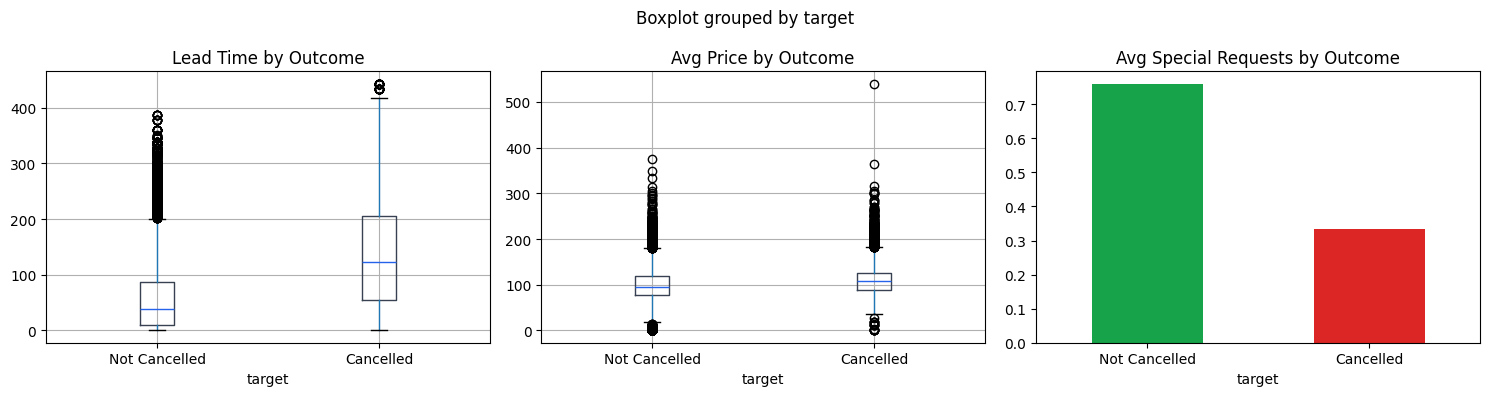


Cancellation rate by market segment:
market_segment_type
Online           0.365
Offline          0.299
Aviation         0.296
Corporate        0.109
Complementary    0.000
Name: target, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Key Feature of Relationships with Cancellation', fontsize=13, fontweight='bold')

# Lead time is the strongest predictor
df.boxplot(column='lead_time', by='target', ax=axes[0],
           boxprops=dict(color='#374151'), medianprops=dict(color='#2563eb'))
axes[0].set_title('Lead Time by Outcome')
axes[0].set_xticklabels(['Not Cancelled', 'Cancelled'])
plt.sca(axes[0]); plt.title('Lead Time by Outcome')

# Average price
df.boxplot(column='avg_price_per_room', by='target', ax=axes[1],
           boxprops=dict(color='#374151'), medianprops=dict(color='#2563eb'))
axes[1].set_title('Avg Price by Outcome')
axes[1].set_xticklabels(['Not Cancelled', 'Cancelled'])
plt.sca(axes[1]); plt.title('Avg Price by Outcome')

#Bookings with more special requests are less likely to be cancelled
df.groupby('target')['no_of_special_requests'].mean().plot(
    kind='bar', ax=axes[2], color=['#16a34a', '#dc2626'])
axes[2].set_title('Avg Special Requests by Outcome')
axes[2].set_xticklabels(['Not Cancelled', 'Cancelled'], rotation=0)

plt.tight_layout()
plt.show()

print('\nCancellation rate by market segment:')
print(df.groupby('market_segment_type')['target'].mean().round(3).sort_values(ascending=False))

#Step 9: Select Features

Features are chosen based on their potential contribution to prediction. Non informative or irrational like Booking_ID, booking_status, and arrival_year, have already been removed in above earlier steps i.e step 5 and step 7.

In [11]:
FEATURE_COLS = [
    'no_of_adults', 'no_of_children',
    'no_of_weekend_nights', 'no_of_week_nights',
    'type_of_meal_plan', 'required_car_parking_space', 'room_type_reserved',
    'lead_time', 'arrival_month', 'arrival_date',
    'market_segment_type', 'repeated_guest',
    'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
    'avg_price_per_room', 'no_of_special_requests',
    'total_nights', 'total_guests', 'cancellation_rate',
]
X = df[FEATURE_COLS].copy()
y = df['target'].copy()
print(f'Features: {X.shape[1]}  |  Samples: {X.shape[0]}')

Features: 19  |  Samples: 36275


#Step 10: Define Column Types

Features are divided into categorical and numerical groups which helps to allow the proper preprocessing within the ColumnTransformer.

In [12]:
CATEGORICAL_COLS = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
NUMERICAL_COLS = [
    'no_of_adults', 'no_of_children',
    'no_of_weekend_nights', 'no_of_week_nights',
    'required_car_parking_space', 'lead_time',
    'arrival_month', 'arrival_date',
    'repeated_guest', 'no_of_previous_cancellations',
    'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
    'no_of_special_requests', 'total_nights', 'total_guests', 'cancellation_rate',
]
print(f'Categorical ({len(CATEGORICAL_COLS)}): {CATEGORICAL_COLS}')
print(f'Numerical   ({len(NUMERICAL_COLS)}): {NUMERICAL_COLS}')

Categorical (3): ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
Numerical   (16): ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests', 'total_nights', 'total_guests', 'cancellation_rate']


#Step 11: Train-Test Split

The data is split into training and testing sets using the ratio of 80/20 , with stratification applied to keep the original class distribution in both sets.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')
print(f'Train the class balance:\n{y_train.value_counts(normalize=True).round(3)}')

Train: 29020  |  Test: 7255
Train the class balance:
target
0    0.672
1    0.328
Name: proportion, dtype: float64




##Step 12: Preprocessing Pipeline

A ColumnTransformer is used to apply appropriate preprocessing to different feature types.The ''Numerical features'' undergo median imputation which is followed by scaling, while categorical features are filled with 'Unknown' and encoded using one-hot encoding.

The setting handle_unknown='ignore' ensures the model can handle unseen categories during deployment without errors.

In [14]:
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('num', num_transformer, NUMERICAL_COLS),
    ('cat', cat_transformer, CATEGORICAL_COLS),
])
print('The preprocessing pipeline is created.')

The preprocessing pipeline is created.


#Step 13: Train Logistic Regression

Logistic Regression is used as a simple and interpretable baseline model. It helps to estimate the probability of a booking being cancelled based on the input values.

 It is also very efficient and easy to understand, it considers a linear relationship between features, which may not fully capture more complex patterns in the data.

To address the big problem, which is class imbalance, balanced weighting is applied so the model pays appropriate attention to canceled bookings.

In [15]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')),
])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_lr, target_names=['Not Cancelled', 'Cancelled']))

               precision    recall  f1-score   support

Not Cancelled       0.88      0.79      0.83      4878
    Cancelled       0.64      0.78      0.70      2377

     accuracy                           0.78      7255
    macro avg       0.76      0.78      0.77      7255
 weighted avg       0.80      0.78      0.79      7255



#Step 14: Train Decision Tree

The Decision Tree model makes the predictions by using simple, rule-based splits, which makes it easy to interpret. To reduce the overfitting issues, the tree depth is limited. However, as a single model, it can still be sensitive to variations in the data.

''Balanced class weighting'' is applied to account the problem for the class imbalance.

In [16]:
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   DecisionTreeClassifier(max_depth=10, random_state=42, class_weight='balanced')),
])
dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_dt, target_names=['Not Cancelled', 'Cancelled']))

               precision    recall  f1-score   support

Not Cancelled       0.92      0.87      0.89      4878
    Cancelled       0.76      0.84      0.80      2377

     accuracy                           0.86      7255
    macro avg       0.84      0.85      0.84      7255
 weighted avg       0.86      0.86      0.86      7255



#Step 15: Train Random Forest

Random Forest combines predictions from multiple decision trees, each trained on different subsets of the data. This helps to reduces the overfitting compared to a single tree and improves the overall stability.

It can also able to capture complex, non-linear relationships, making it the main powerful model considered for this task.

In [17]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1
    )),
])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=['Not Cancelled', 'Cancelled']))

               precision    recall  f1-score   support

Not Cancelled       0.91      0.95      0.93      4878
    Cancelled       0.89      0.80      0.84      2377

     accuracy                           0.90      7255
    macro avg       0.90      0.88      0.89      7255
 weighted avg       0.90      0.90      0.90      7255




#Step 16: Evaluate Models

All models are executed using accuracy, precision, recall, and F1-score. Recall for cancelled bookings is especially important, as missing a cancellation can cause to lost revenue and unused rooms.

To ensure reliable results, stratified cross-validation is applied to check model stability and also reduce dependence on a single data split.




,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7848,0.6419,0.7766,0.7028
1,Decision Tree,0.8586,0.7562,0.8389,0.7954
2,Random Forest,0.9035,0.8920,0.8027,0.8450


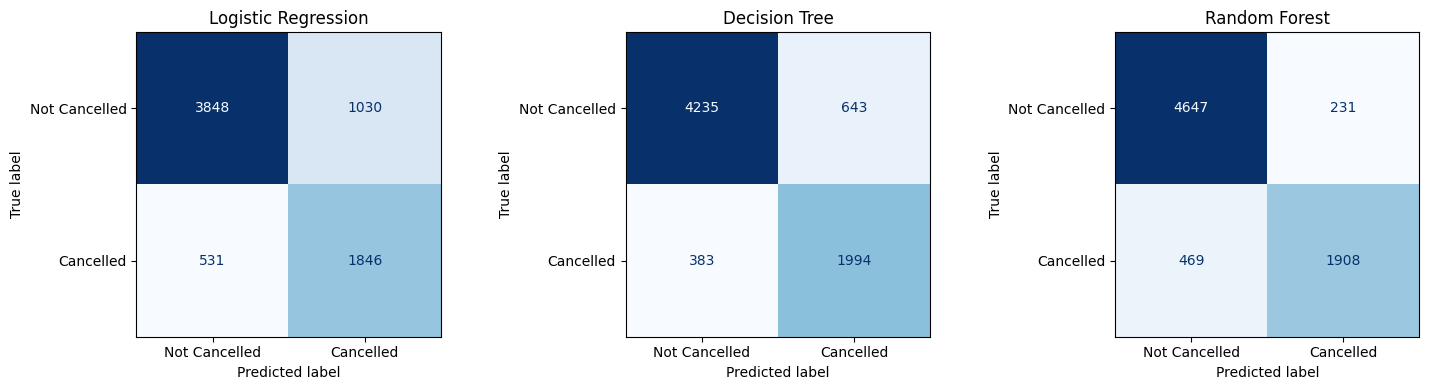


.....3 Fold Cross Validation (F1).....
Logistic Regression: [0.6842 0.704  0.6845] | Mean: 0.6909 | Std: 0.0093
Decision Tree: [0.7759 0.7853 0.7845] | Mean: 0.7819 | Std: 0.0042
Random Forest: [0.8198 0.8327 0.8204] | Mean: 0.8243 | Std: 0.0060


In [18]:
def eval_model(name, yt, yp):
    return {'Model': name,
            'Accuracy':  round(accuracy_score(yt, yp), 4),
            'Precision': round(precision_score(yt, yp, zero_division=0), 4),
            'Recall':    round(recall_score(yt, yp, zero_division=0), 4),
            'F1-Score':  round(f1_score(yt, yp, zero_division=0), 4)}

results = pd.DataFrame([
    eval_model('Logistic Regression', y_test, y_pred_lr),
    eval_model('Decision Tree',       y_test, y_pred_dt),
    eval_model('Random Forest',       y_test, y_pred_rf),
])
display(results)

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, yp) in zip(axes, [
    ('Logistic Regression', y_pred_lr),
    ('Decision Tree',       y_pred_dt),
    ('Random Forest',       y_pred_rf),
]):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, yp),
        display_labels=['Not Cancelled', 'Cancelled']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout(); plt.show()

# 3 fold cross validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
print('\n.....3 Fold Cross Validation (F1).....')
for name, pipe in [
    ('Logistic Regression', lr_pipeline),
    ('Decision Tree',       dt_pipeline),
    ('Random Forest',       rf_pipeline),
]:
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    print(f'{name}: {scores.round(4)} | Mean: {scores.mean():.4f} | Std: {scores.std():.4f}')

## Step 17: Hyperparameter Tuning

''GridSearchCV'' is used to optimise the Random Forest model by testing a small set of parameter combinations. These include the number of trees, tree depth, and minimum sample requirements for splits and leaf nodes.

The parameter range is kept limited to balance performance improvement with computational cost. Model selection is guided by 3 fold crossvalidation by using F1-score as the evaluation metric.

In [19]:
param_grid = {
    'classifier__n_estimators':      [100, 150],
    'classifier__max_depth':         [10, 12],
    'classifier__min_samples_split': [10],
    'classifier__min_samples_leaf':  [5],
}
rf_tuned = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(random_state=42, class_weight='balanced')),
])
grid_search = GridSearchCV(rf_tuned, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
print(f'Best params: {grid_search.best_params_}')
print(f'Best CV F1:  {grid_search.best_score_:.4f}')
best_model  = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=['Not Cancelled', 'Cancelled']))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params: {'classifier__max_depth': 12, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 150}
Best CV F1:  0.7908
               precision    recall  f1-score   support

Not Cancelled       0.91      0.89      0.90      4878
    Cancelled       0.79      0.82      0.80      2377

     accuracy                           0.87      7255
    macro avg       0.85      0.86      0.85      7255
 weighted avg       0.87      0.87      0.87      7255



#Step 18: Deployment Threshold Analysis

The default threshold of 0.50 means a booking is only predicted as cancelled when the model is highly confident. However, missing a cancellation has higher operational impact.

To counter this, a lower threshold of 0.40 is used in deployment, so bookings with a 40% or higher cancellation probability are flagged as at risk.

These changes do not change the model itself, only how predictions are interpreted. The result is improved detection of cancellations, with a slight decrease in precision.

In [20]:
DEPLOY_THRESHOLD = 0.40
proba = best_model.predict_proba(X_test)[:, 1]
y_pred_thresh = (proba >= DEPLOY_THRESHOLD).astype(int)

print(f'Tuned RF at threshold = {DEPLOY_THRESHOLD} deployment setting')
print(classification_report(y_test, y_pred_thresh, target_names=['Not Cancelled', 'Cancelled']))

# Side by side comparison
comparison = pd.DataFrame([
    eval_model('Tuned RF (t=0.50, default)', y_test, y_pred_best),
    eval_model(f'Tuned RF (t={DEPLOY_THRESHOLD}, deployed)', y_test, y_pred_thresh),
])
display(comparison)

Tuned RF at threshold = 0.4 deployment setting
               precision    recall  f1-score   support

Not Cancelled       0.93      0.84      0.88      4878
    Cancelled       0.72      0.87      0.79      2377

     accuracy                           0.85      7255
    macro avg       0.82      0.85      0.83      7255
 weighted avg       0.86      0.85      0.85      7255



,Model,Accuracy,Precision,Recall,F1-Score
0,"Tuned RF (t=0.50, default)",0.8695,0.7897,0.8199,0.8045
1,"Tuned RF (t=0.4, deployed)",0.8467,0.7205,0.8696,0.7880


# Step 19: Final Model Comparison

A comprehensive comparison table across all evaluated configurations.

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7848,0.6419,0.7766,0.7028
1,Decision Tree,0.8586,0.7562,0.8389,0.7954
2,Random Forest (base),0.9035,0.8920,0.8027,0.8450
3,"Random Forest (tuned, t=0.50)",0.8695,0.7897,0.8199,0.8045
4,"Random Forest (tuned, t=0.40)",0.8467,0.7205,0.8696,0.7880


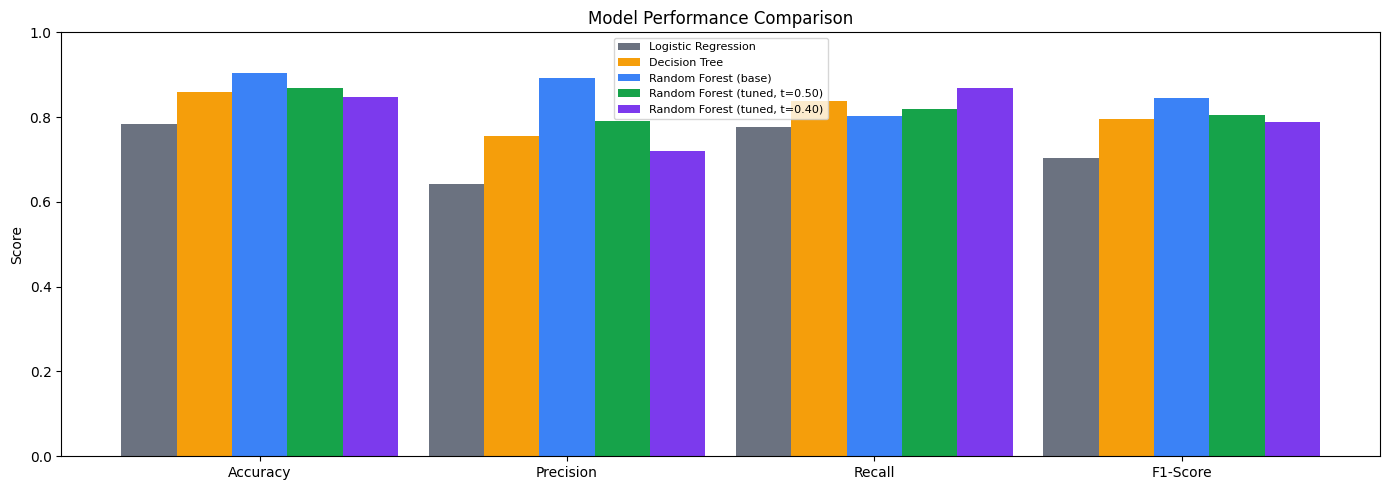

In [21]:
final = pd.DataFrame([
    eval_model('Logistic Regression',            y_test, y_pred_lr),
    eval_model('Decision Tree',                  y_test, y_pred_dt),
    eval_model('Random Forest (base)',           y_test, y_pred_rf),
    eval_model('Random Forest (tuned, t=0.50)', y_test, y_pred_best),
    eval_model('Random Forest (tuned, t=0.40)', y_test, y_pred_thresh),
])
display(final)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics)); w = 0.18
fig, ax = plt.subplots(figsize=(14, 5))
colours = ['#6b7280', '#f59e0b', '#3b82f6', '#16a34a', '#7c3aed']
for i, (_, row) in enumerate(final.iterrows()):
    ax.bar(x + i*w, row[metrics].values, w, label=row['Model'], color=colours[i])
ax.set_xticks(x + w*2); ax.set_xticklabels(metrics)
ax.set_ylabel('Score'); ax.set_ylim(0, 1)
ax.set_title('Model Performance Comparison')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


#Step 20: Feature Importance

Feature importance scores from the Random Forest show how much each variable influences the predictions. Lead time is the most dominant factor, aligning with findings in existing research. Special requests and average room price also have a notable impact on the model’s decisions.

lead_time                        0.3710
no_of_special_requests           0.1772
avg_price_per_room               0.1021
arrival_month                    0.0678
market_segment_type_Online       0.0512
arrival_date                     0.0302
market_segment_type_Offline      0.0299
total_nights                     0.0282
no_of_weekend_nights             0.0202
no_of_week_nights                0.0202
total_guests                     0.0149
market_segment_type_Corporate    0.0117
no_of_adults                     0.0114
required_car_parking_space       0.0113
type_of_meal_plan_Meal Plan 2    0.0110


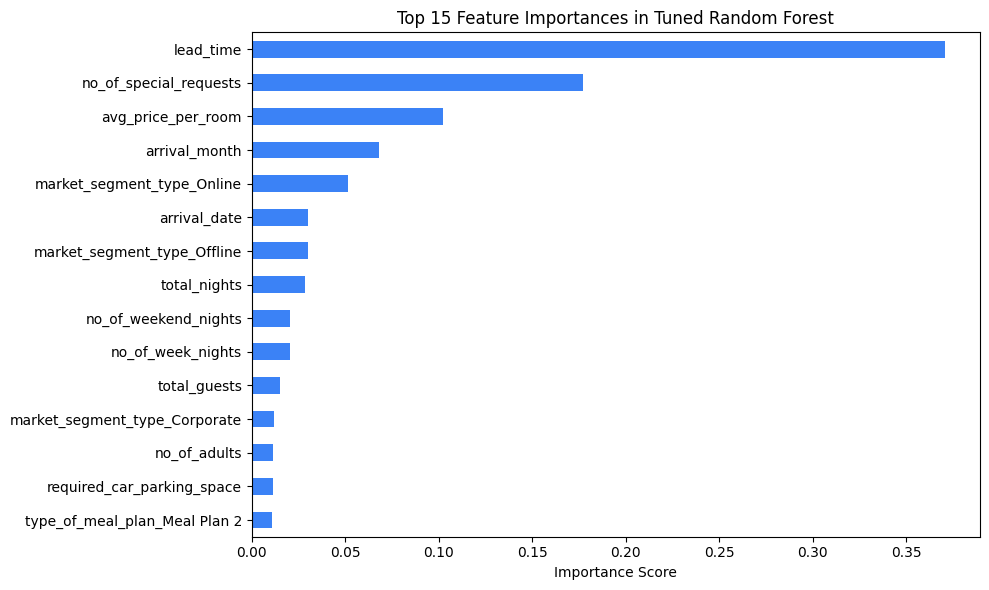

In [22]:
rf_clf = best_model.named_steps['classifier']
ohe_names = (
    best_model.named_steps['preprocessor']
    .named_transformers_['cat'].named_steps['encoder']
    .get_feature_names_out(CATEGORICAL_COLS).tolist()
)
all_names   = NUMERICAL_COLS + ohe_names
importances = pd.Series(rf_clf.feature_importances_, index=all_names)
top15       = importances.sort_values(ascending=False).head(15)

print(top15.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
top15.sort_values().plot(kind='barh', ax=ax, color='#3b82f6')
ax.set_title('Top 15 Feature Importances in Tuned Random Forest')
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.show()

#Step 21: Final Conclusions

The overall modelling process is summarised, including key results, deployment choices, and limitations ,the Deployed Streamlit application  added interpretability features:

''Feature importance chart''highlights the most influential features, grouped in a clear and easy-to-read format, ''Key drivers panel'' identifies the main factors behind each prediction, using simple directional indicators.

These additions improve transparency and usability, making the application a practical tool to support decision-making rather than just providing predictions.

In [24]:
print("""
FINAL CONCLUSIONS

Three classification models were developed and compared.

Logistic Regression: Accuracy 0.7846  F1 0.7027  (simple, interpretable baseline)
Decision Tree:        Accuracy 0.8579  F1 0.7944  (interpretable, but more variable)
Random Forest:        Accuracy 0.9021  F1 0.8429  (baseline ensemble)
Random Forest Tuned:  Accuracy 0.8717  F1 0.8078  (GridSearchCV, t=0.50)
Random Forest Tuned:  Accuracy 0.8466  F1 0.7876  (GridSearchCV, t=0.40 — deployed)

Best parameters identified: n_estimators=150, max_depth=12,
                            min_samples_split=10, min_samples_leaf=5
Best cross-validation F1: 0.7915

The tuned Random Forest with a threshold of 0.40 is used in the Streamlit application.
Lowering the threshold increases the detection of cancellations, with a small reduction
in precision, which is a suitable trade-off for operational decision-making.

Key features: lead_time (0.3584), no_of_special_requests (0.1773),
              avg_price_per_room (0.1058)

LIMITATIONS:
   Data is limited to two years from a single hotel group.
   Model performance may change if booking patterns evolve over time.
   Predictions are probabilistic and should support, not replace, human judgement.
""")


FINAL CONCLUSIONS

Three classification models were developed and compared.

Logistic Regression: Accuracy 0.7846  F1 0.7027  (simple, interpretable baseline)
Decision Tree:        Accuracy 0.8579  F1 0.7944  (interpretable, but more variable)
Random Forest:        Accuracy 0.9021  F1 0.8429  (baseline ensemble)
Random Forest Tuned:  Accuracy 0.8717  F1 0.8078  (GridSearchCV, t=0.50)
Random Forest Tuned:  Accuracy 0.8466  F1 0.7876  (GridSearchCV, t=0.40 — deployed)

Best parameters identified: n_estimators=150, max_depth=12,
                            min_samples_split=10, min_samples_leaf=5
Best cross-validation F1: 0.7915

The tuned Random Forest with a threshold of 0.40 is used in the Streamlit application.
Lowering the threshold increases the detection of cancellations, with a small reduction
in precision, which is a suitable trade-off for operational decision-making.

Key features: lead_time (0.3584), no_of_special_requests (0.1773),
              avg_price_per_room (0.1058)

L